# Application: Conformal Mappings

Explore angle-preserving transformations and their applications.

**Prerequisites**: Notebooks #1, #2 | **Time**: ~25 min

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import complexplorer as cp

## What is a Conformal Map?

**Definition**: A conformal map preserves angles between curves.

**Key property**: If $f'(z_0) \neq 0$, then $f$ is conformal at $z_0$

**Applications**:
- Fluid dynamics: Potential flow
- Electrostatics: Field mapping
- Cartography: Map projections
- Complex analysis: Riemann mapping theorem

**Visualization**: Use pair plots to see domain → codomain transformation!

## 1. Möbius Transformations

**Definition**: Linear fractional transformations
$$f(z) = \frac{az + b}{cz + d}, \quad ad - bc \neq 0$$

**Properties**:
- Map circles/lines to circles/lines
- Form a group under composition
- Three points determine a unique Möbius transformation
- Conformal on extended complex plane ℂ ∪ {∞}

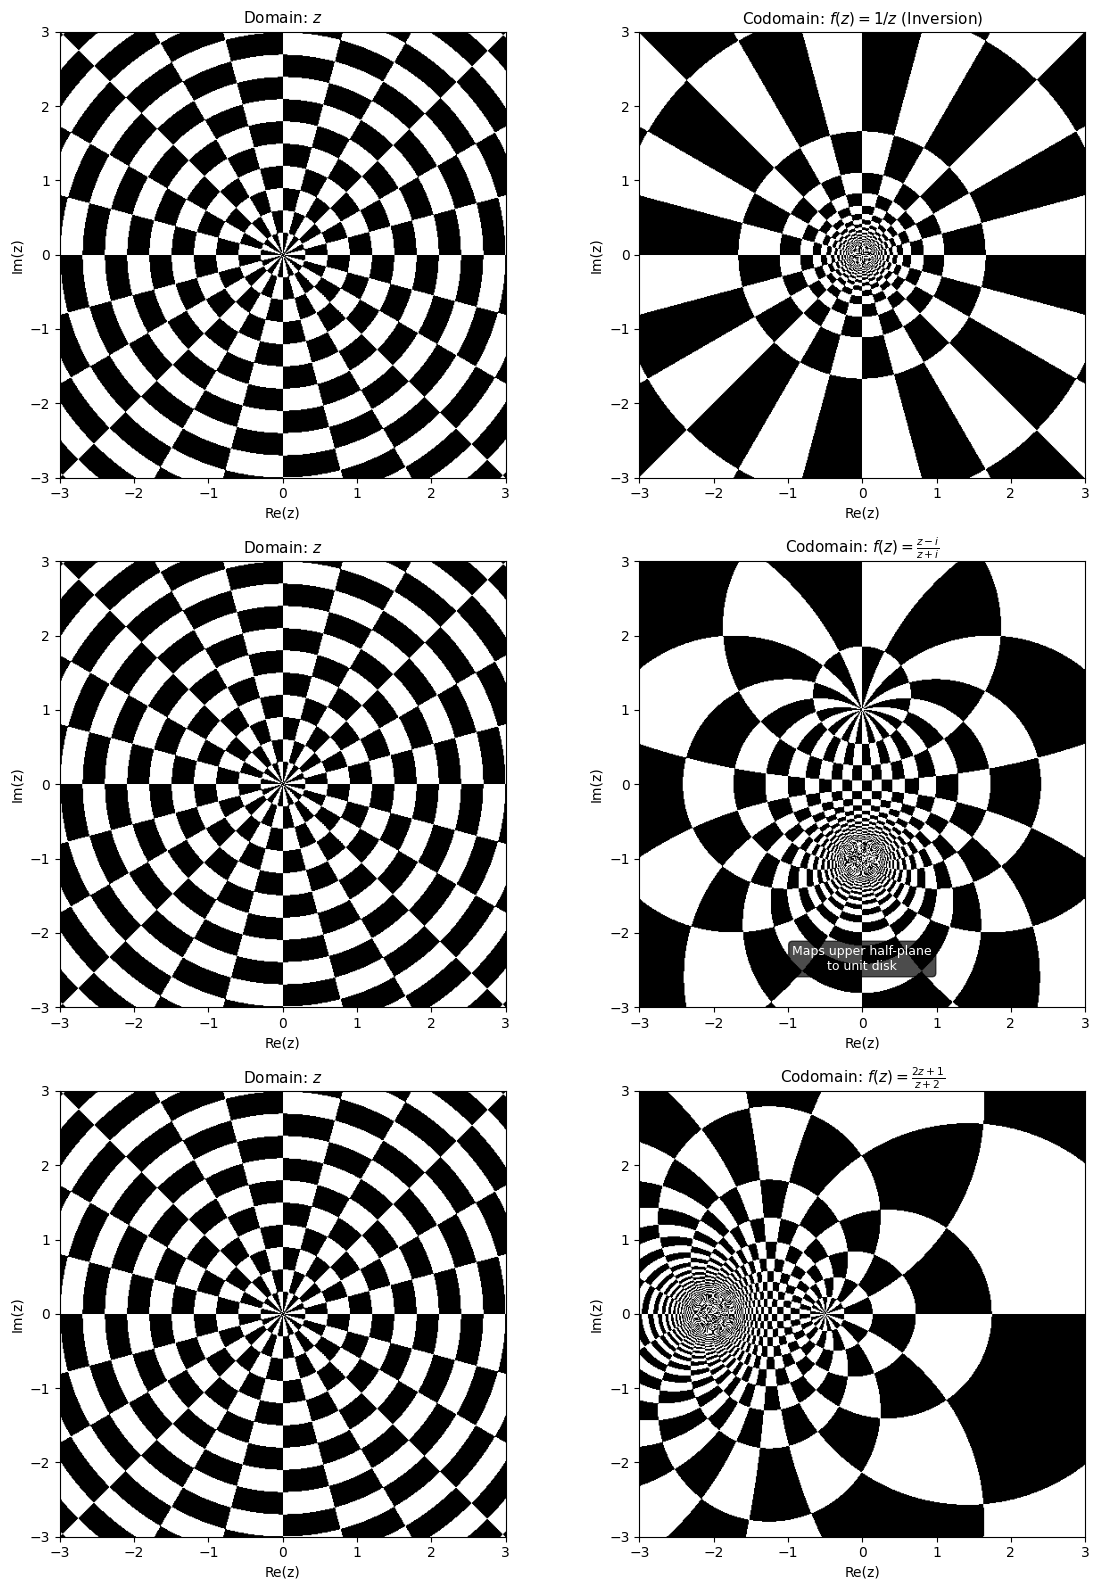


✓ Notice how the polar grid transforms!
  Circles and radial lines map to circles/lines


In [15]:
# Example Möbius transformations
def mobius_1(z):
    """f(z) = 1/z - inversion"""
    return 1 / (z + 1e-10)

def mobius_2(z):
    """f(z) = (z - i)/(z + i) - maps upper half-plane to unit disk"""
    return (z - 1j) / (z + 1j + 1e-10)

def mobius_3(z):
    """f(z) = (2z + 1)/(z + 2) - general Möbius"""
    return (2*z + 1) / (z + 2 + 1e-10)

domain = cp.Rectangle(re_length=6, im_length=6)
cmap = cp.PolarChessboard(phase_sectors=12, spacing=0.3)

fig, axes = plt.subplots(3, 2, figsize=(12, 16))

# Inversion f(z) = 1/z
cp.plot(domain, lambda z: z, cmap=cmap, ax=axes[0,0], resolution=500)
axes[0,0].set_title(r"Domain: $z$", fontsize=11)
cp.plot(domain, mobius_1, cmap=cmap, ax=axes[0,1], resolution=500)
axes[0,1].set_title(r"Codomain: $f(z) = 1/z$ (Inversion)", fontsize=11)

# Half-plane to disk
cp.plot(domain, lambda z: z, cmap=cmap, ax=axes[1,0], resolution=500)
axes[1,0].set_title(r"Domain: $z$", fontsize=11)
cp.plot(domain, mobius_2, cmap=cmap, ax=axes[1,1], resolution=500)
axes[1,1].set_title(r"Codomain: $f(z) = \frac{z-i}{z+i}$", fontsize=11)
axes[1,1].text(0, -2.5, "Maps upper half-plane\nto unit disk", 
               ha='center', fontsize=9, color='white',
               bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# General Möbius
cp.plot(domain, lambda z: z, cmap=cmap, ax=axes[2,0], resolution=500)
axes[2,0].set_title(r"Domain: $z$", fontsize=11)
cp.plot(domain, mobius_3, cmap=cmap, ax=axes[2,1], resolution=500)
axes[2,1].set_title(r"Codomain: $f(z) = \frac{2z+1}{z+2}$", fontsize=11)

plt.tight_layout()
plt.show()

print("\n✓ Notice how the polar grid transforms!")
print("  Circles and radial lines map to circles/lines")

## 2. Joukowsky Transform

**Definition**: $$f(z) = z + \frac{1}{z}$$

**Applications**:
- **Aerodynamics**: Maps circles to airfoil shapes
- **Potential flow**: Flow around wing profiles
- **Kutta condition**: Sharp trailing edge

**Key feature**: Circle through z = ±1 → airfoil shape

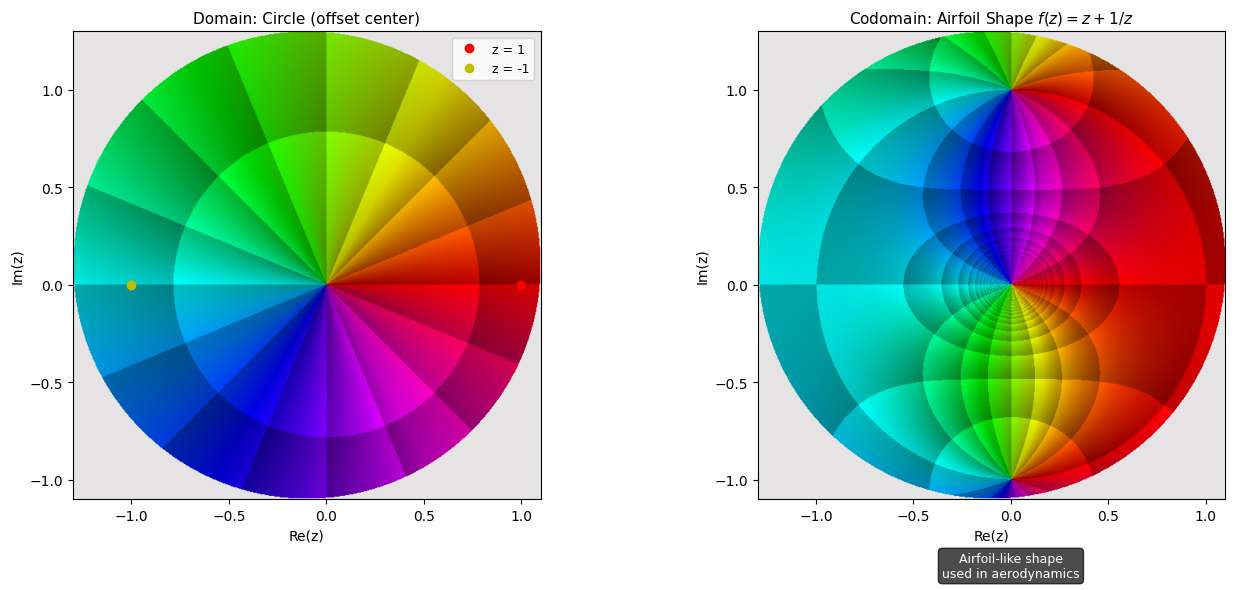


✓ The Joukowsky transform maps a circle to an airfoil!
  By adjusting the circle center, you can design different airfoils


In [16]:
# Joukowsky transform
def joukowsky(z):
    """Joukowsky airfoil transformation."""
    return z + 1 / (z + 1e-10)

# Domain: circle that passes through z = 1
domain_jouk = cp.Disk(radius=1.2, center=-0.1+0.1j)
cmap = cp.Phase(phase_sectors=8, auto_scale_r=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cp.plot(domain_jouk, lambda z: z, cmap=cmap, ax=axes[0], resolution=600)
axes[0].set_title(r"Domain: Circle (offset center)", fontsize=11)
axes[0].plot([1], [0], 'ro', markersize=6, label='z = 1')
axes[0].plot([-1], [0], 'yo', markersize=6, label='z = -1')
axes[0].legend(loc='upper right', fontsize=9)

cp.plot(domain_jouk, joukowsky, cmap=cmap, ax=axes[1], resolution=600)
axes[1].set_title(r"Codomain: Airfoil Shape $f(z) = z + 1/z$", fontsize=11)
axes[1].text(0, -1.5, "Airfoil-like shape\nused in aerodynamics", 
             ha='center', fontsize=9, color='white',
             bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n✓ The Joukowsky transform maps a circle to an airfoil!")
print("  By adjusting the circle center, you can design different airfoils")

## 3. Exponential and Logarithm

**Exponential**: $f(z) = e^z$
- Maps vertical lines to circles
- Maps horizontal lines to rays
- Periodic in imaginary direction: $e^{z + 2\pi i} = e^z$

**Logarithm**: $f(z) = \log z$ (inverse of exponential)
- Maps circles to vertical lines
- Maps rays to horizontal lines
- Multi-valued: requires branch cut

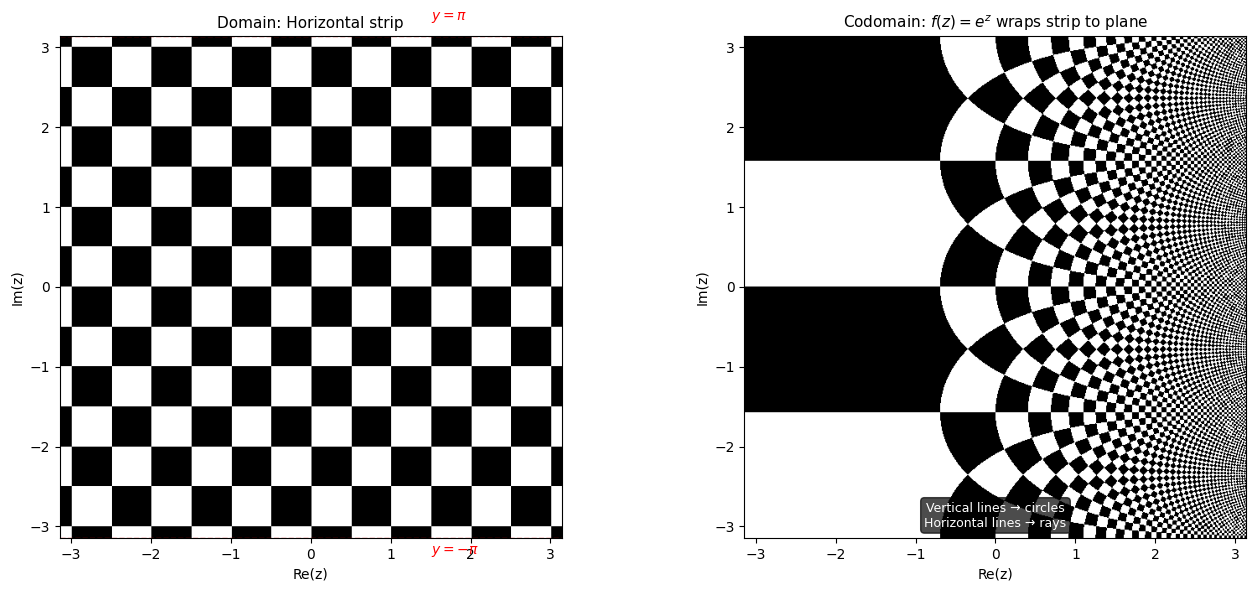


✓ Exponential map wraps the strip onto the complex plane!
  The Cartesian grid becomes a polar grid


In [17]:
# Exponential map
def exp_map(z):
    return np.exp(z)

# Domain: horizontal strip
domain_strip = cp.Rectangle(re_length=4, im_length=2*np.pi, center=0+0j)
cmap = cp.Chessboard(spacing=0.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cp.plot(domain_strip, lambda z: z, cmap=cmap, ax=axes[0], resolution=600)
axes[0].set_title(r"Domain: Horizontal strip", fontsize=11)
axes[0].axhline(y=np.pi, color='red', linestyle='--', alpha=0.7, linewidth=1)
axes[0].axhline(y=-np.pi, color='red', linestyle='--', alpha=0.7, linewidth=1)
axes[0].text(1.5, np.pi + 0.2, r'$y = \pi$', color='red', fontsize=10)
axes[0].text(1.5, -np.pi - 0.2, r'$y = -\pi$', color='red', fontsize=10)

cp.plot(domain_strip, exp_map, cmap=cmap, ax=axes[1], resolution=600)
axes[1].set_title(r"Codomain: $f(z) = e^z$ wraps strip to plane", fontsize=11)
axes[1].text(0, -3, "Vertical lines → circles\nHorizontal lines → rays", 
             ha='center', fontsize=9, color='white',
             bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n✓ Exponential map wraps the strip onto the complex plane!")
print("  The Cartesian grid becomes a polar grid")

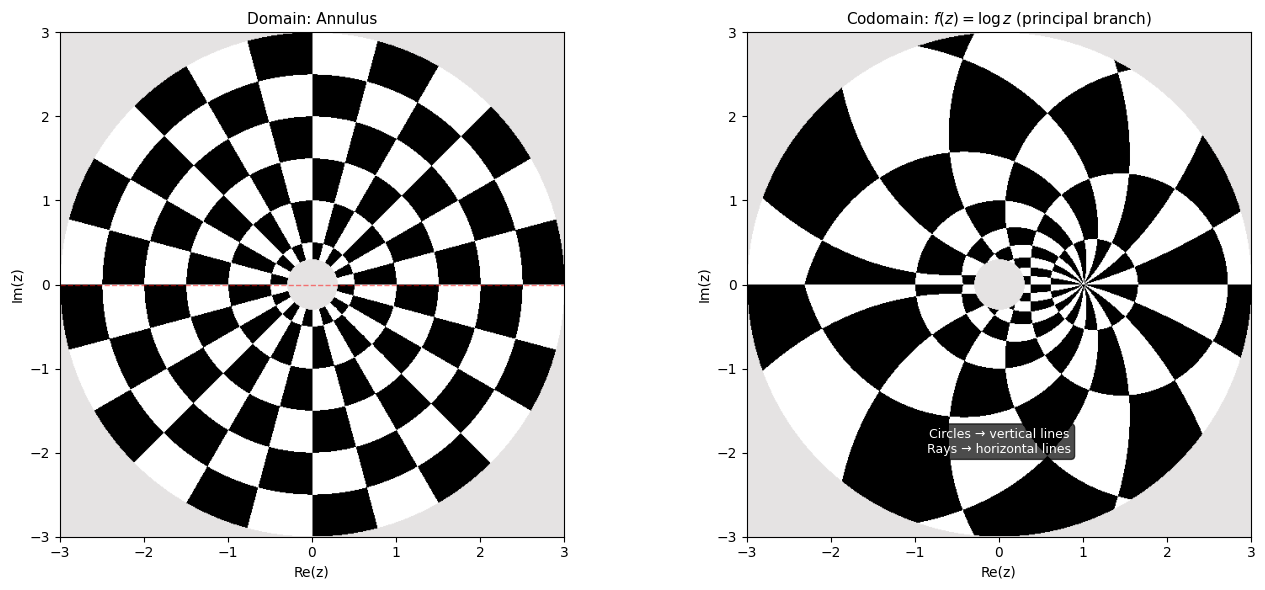


✓ Logarithm is the inverse of exponential!
  Note: We avoid negative real axis (branch cut)


In [18]:
# Logarithm (principal branch)
def log_map(z):
    """Principal branch of logarithm."""
    return np.log(z + 1e-10)

# Domain: annulus avoiding branch cut
domain_annulus = cp.Annulus(inner_radius=0.3, outer_radius=3)
cmap = cp.PolarChessboard(phase_sectors=12, spacing=0.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cp.plot(domain_annulus, lambda z: z, cmap=cmap, ax=axes[0], resolution=600)
axes[0].set_title(r"Domain: Annulus", fontsize=11)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)

cp.plot(domain_annulus, log_map, cmap=cmap, ax=axes[1], resolution=600)
axes[1].set_title(r"Codomain: $f(z) = \log z$ (principal branch)", fontsize=11)
axes[1].text(0, -2, "Circles → vertical lines\nRays → horizontal lines", 
             ha='center', fontsize=9, color='white',
             bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n✓ Logarithm is the inverse of exponential!")
print("  Note: We avoid negative real axis (branch cut)")

## 4. Power Functions

**Definition**: $f(z) = z^n$ for integer $n$

**Properties**:
- $n > 1$: Maps plane onto itself with branching
- $n = 2$: Squaring map (common in dynamics)
- $n = -1$: Inversion (Möbius)
- Angles multiplied by $n$ at origin

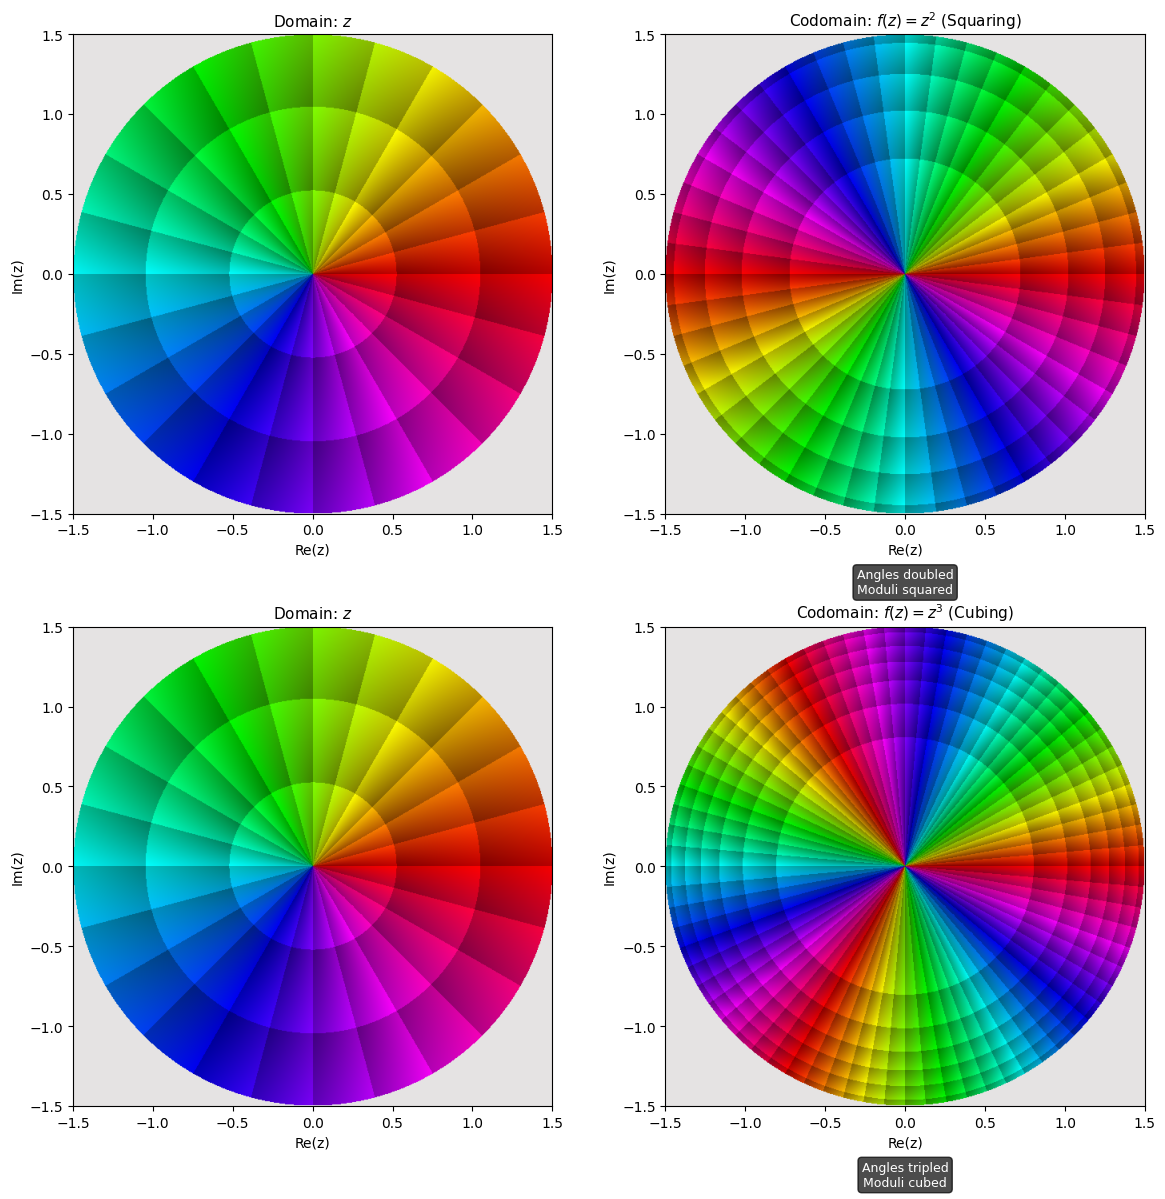


✓ Power functions multiply angles by n!
  f(z) = z^n wraps the plane n times around origin


In [19]:
# Power functions
def square(z):
    return z**2

def cube(z):
    return z**3

domain_disk = cp.Disk(radius=1.5)
cmap = cp.Phase(phase_sectors=12, auto_scale_r=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Squaring
cp.plot(domain_disk, lambda z: z, cmap=cmap, ax=axes[0,0], resolution=600)
axes[0,0].set_title(r"Domain: $z$", fontsize=11)
cp.plot(domain_disk, square, cmap=cmap, ax=axes[0,1], resolution=600)
axes[0,1].set_title(r"Codomain: $f(z) = z^2$ (Squaring)", fontsize=11)
axes[0,1].text(0, -2, "Angles doubled\nModuli squared", 
               ha='center', fontsize=9, color='white',
               bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# Cubing
cp.plot(domain_disk, lambda z: z, cmap=cmap, ax=axes[1,0], resolution=600)
axes[1,0].set_title(r"Domain: $z$", fontsize=11)
cp.plot(domain_disk, cube, cmap=cmap, ax=axes[1,1], resolution=600)
axes[1,1].set_title(r"Codomain: $f(z) = z^3$ (Cubing)", fontsize=11)
axes[1,1].text(0, -2, "Angles tripled\nModuli cubed", 
               ha='center', fontsize=9, color='white',
               bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n✓ Power functions multiply angles by n!")
print("  f(z) = z^n wraps the plane n times around origin")

## 5. Composition of Conformal Maps

**Key theorem**: Composition of conformal maps is conformal

**Strategy**: Build complex mappings from simple ones

**Example**: Map half-plane → disk → airfoil

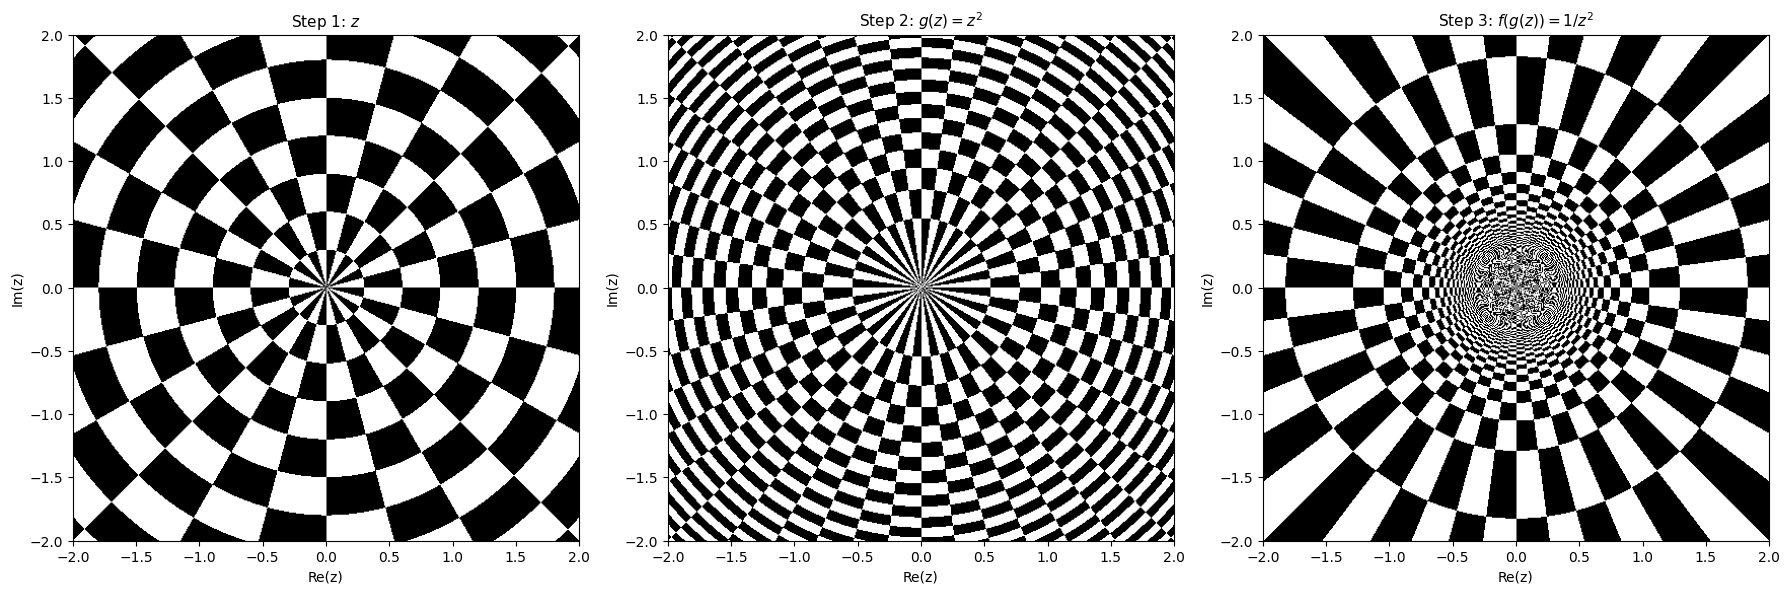


✓ Composition: First square, then invert
  Build complex mappings from simple building blocks!


In [20]:
# Composition example: f(g(z))
def composed_map(z):
    """f(g(z)) where g(z) = z^2 and f(z) = 1/z"""
    g = z**2
    return 1 / (g + 1e-10)

domain = cp.Rectangle(re_length=4, im_length=4)
cmap = cp.PolarChessboard(phase_sectors=12, spacing=0.3)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Domain
z = domain.mesh(500)
mask = domain.outmask(500)
rgb = cmap.rgb(z, outmask=mask)
axes[0].imshow(rgb, origin='lower', extent=[-2, 2, -2, 2])
axes[0].set_title(r"Step 1: $z$", fontsize=11)
axes[0].set_xlabel('Re(z)')
axes[0].set_ylabel('Im(z)')

# Intermediate: g(z) = z^2
gz = z**2
rgb_g = cmap.rgb(gz, outmask=mask)
axes[1].imshow(rgb_g, origin='lower', extent=[-2, 2, -2, 2])
axes[1].set_title(r"Step 2: $g(z) = z^2$", fontsize=11)
axes[1].set_xlabel('Re(z)')
axes[1].set_ylabel('Im(z)')

# Final: f(g(z)) = 1/z^2
cp.plot(domain, composed_map, cmap=cmap, ax=axes[2], resolution=500)
axes[2].set_title(r"Step 3: $f(g(z)) = 1/z^2$", fontsize=11)

plt.tight_layout()
plt.show()

print("\n✓ Composition: First square, then invert")
print("  Build complex mappings from simple building blocks!")

## Applications in Physics and Engineering

### Fluid Dynamics
- **Potential flow**: Velocity field = complex derivative of potential
- **Conformal mapping**: Transform simple flow to complex geometry
- **Example**: Flow around cylinder → flow around airfoil (Joukowsky)

### Electrostatics
- **Electric field**: Maps conformally like fluid flow
- **Boundary problems**: Use conformal maps to solve Laplace equation
- **Capacitance**: Computed via conformal modulus

### Cartography
- **Mercator projection**: Conformal map from sphere to cylinder
- **Stereographic projection**: Sphere to plane (Riemann sphere!)
- **Preserves angles**: Useful for navigation

### Complex Analysis
- **Riemann mapping theorem**: Every simply connected domain (≠ ℂ) can be mapped conformally to unit disk
- **Uniformization**: Classification of Riemann surfaces
- **Moduli spaces**: Deformation theory

## Summary

✅ Möbius transformations: Map circles/lines to circles/lines
✅ Joukowsky transform: Circles to airfoils
✅ Exponential/logarithm: Strip ↔ plane
✅ Power functions: Angle multiplication
✅ Composition: Build complex from simple
✅ Applications: Fluid flow, electrostatics, cartography

## Mathematical Context

Conformal maps are central to:
- **Complex analysis**: Riemann mapping theorem
- **Differential geometry**: Angle-preserving maps
- **Physics**: Potential theory, 2D field equations
- **Engineering**: Airfoil design, heat transfer

## Recommended Reading

- Needham: "Visual Complex Analysis" (Chapter 3)
- Ahlfors: "Complex Analysis" (Chapters 3-4)
- Churchill & Brown: "Complex Variables and Applications"

Beautiful geometry meets practical applications! 🎨🛩️